---
title: Is it hacked?
author: Mihail Plesa
date: 04/15/2023
format:
    html:
        code-folde: false
---

# Is it hacked? 
## Detecting web defacement with deep learning using fastai library

## Introduction

In this short tutorial, we construct a simple classifier for detecting web defacement using fast.ai library. Currently, I'm taking Jeremy Howard's course ([Practical Deep Learning for Coders - Part 1](https://course.fast.ai)) and I'm thrilled about it. I've coded various DL models in the past (especially for cybersecurity), but I only used TensorFlow. 
Recently, I wanted to try PyTorch since it seems that it takes over the market. In the past, I had heard of fastai as a PyTorch-based library, but because I was using TensorFlow, I didn't pay much attention to it. 
Now, I'm impressed by what this library can do and I want to share this with you. 
Don't expect to see a state-of-the-art model, I'm only experimenting with fastai for cybersecurity related problems 😁

Just to be more clear: you know when a website is hacked and the hackers display some message on the home page? 
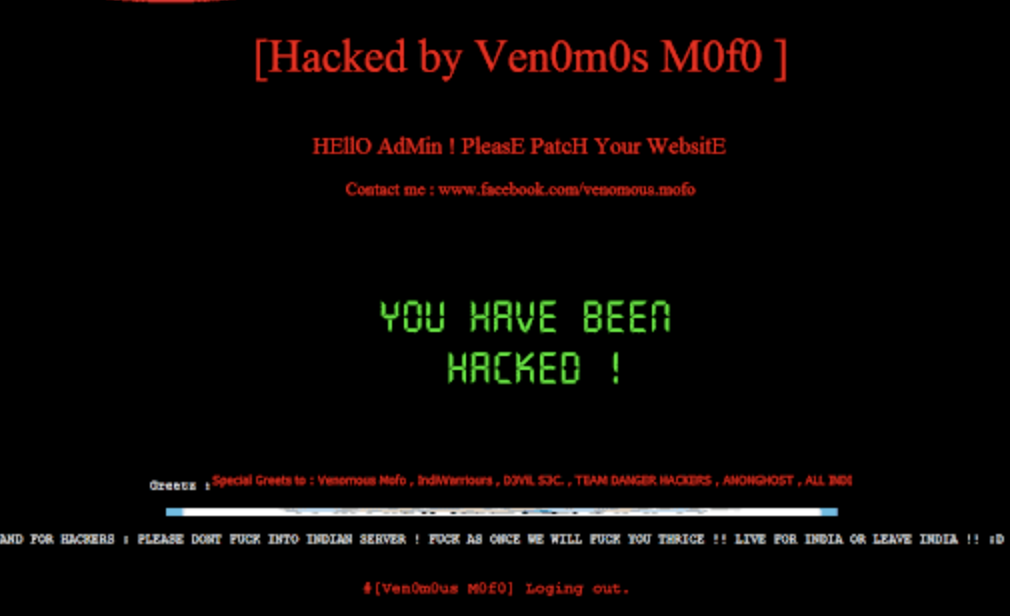


This is web defacement and this we are trying to detect it. Why? Well, if your site was defaced, the first thing you do is to put it in maintenance mode. Wouldn't it be nice if you had a DL model that would warn you instantly when a website has been defaced? If you want to know how you might do that, keep reading 🤓

## Step 0: Update fastai and duckduckgo_search

We will use duckduckgo_search to construct our dataset of defaced and non-defaced websites. 

In [ ]:
!pip install -Uqq fastai duckduckgo_search

## Step 1: Download images of defaced and non-defaced websites

In [9]:
from duckduckgo_search import ddg_images
from fastcore.all import *

def search_images(term, max_images=3000):
    print(f"Searching for '{term}'")
    return L(ddg_images(term, max_results=max_images)).itemgot('image')

Here is an example:

In [4]:
urls = search_images('example of defaced webpage', max_images=1)
urls[0]

Searching for 'example of defaced webpage'


'https://blog.sucuri.net/wp-content/uploads/2020/04/image1-600x419.png'

Now, we download the image from that URL and saved it locally in a file named defaced.jpg. To do this, we use another "fast" library called [fastdownload](https://fastdownload.fast.aihttps://fastdownload.fast.ai). 

In [5]:
from fastdownload import download_url
dest = 'defaced.jpg'
download_url(urls[0], dest, show_progress=False)

Path('defaced.jpg')

To check if we saved the right image, we open it using [PIL](https://pillow.readthedocs.io/en/stable/). The [to_thumb](https://docs.fast.ai/vision.core.html#image.to_thumb) function produces a 256x256 thumbnail version of the image.

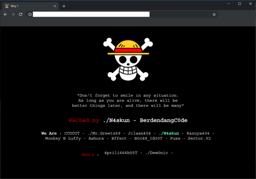

In [7]:
from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

Now we repeat for a non-defaced website.

Searching for 'example of normal webpage'


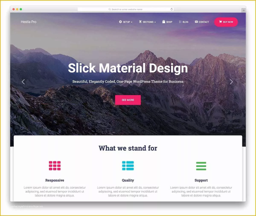

In [8]:
download_url(search_images('example of normal webpage', max_images=1)[0], 'non-defaced.jpg', show_progress=False)
Image.open('non-defaced.jpg').to_thumb(256,256)

Let's build our dataset. We search for defaced and on-defaced websites.

In [36]:
searches = 'defaced homepage webpage','nice homepage webpage'
path = Path('defaced_or_not')
from time import sleep

for o in searches:
    dest = (path/o)
    print(path, o , dest)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'example of a {o}'))
    sleep(10)
    resize_images(path/o, max_size=400, dest=path/o)

defaced_or_not defaced homepage webpage defaced_or_not/defaced homepage webpage
Searching for 'example of a defaced homepage webpage'


/opt/conda/lib/python3.7/site-packages/PIL/Image.py:1018: UserWarning: Couldn't allocate palette entry for transparency
  warnings.warn("Couldn't allocate palette entry for transparency")
/opt/conda/lib/python3.7/site-packages/PIL/Image.py:1018: UserWarning: Couldn't allocate palette entry for transparency
  warnings.warn("Couldn't allocate palette entry for transparency")
/opt/conda/lib/python3.7/site-packages/PIL/Image.py:963: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "
/opt/conda/lib/python3.7/site-packages/PIL/Image.py:963: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "


defaced_or_not nice homepage webpage defaced_or_not/nice homepage webpage
Searching for 'example of a nice homepage webpage'


/opt/conda/lib/python3.7/site-packages/PIL/Image.py:1018: UserWarning: Couldn't allocate palette entry for transparency
  warnings.warn("Couldn't allocate palette entry for transparency")


Delete all images that were downloaded incorrectly.

In [37]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

7

In [42]:
print(len(os.listdir(path/'defaced homepage webpage')))
print(len(os.listdir(path/'nice homepage webpage')))

360
218


We have 360 images of defaced websites and 218 images of non-defaced websites.

## Step 2: Train the model

To train a model, we'll need `DataLoaders`, which is an object that contains a *training set* (the images used to create a model) and a *validation set* (the images used to check the accuracy of a model -- not used during training). In `fastai` we can create that easily using a `DataBlock`, and view sample images from it:

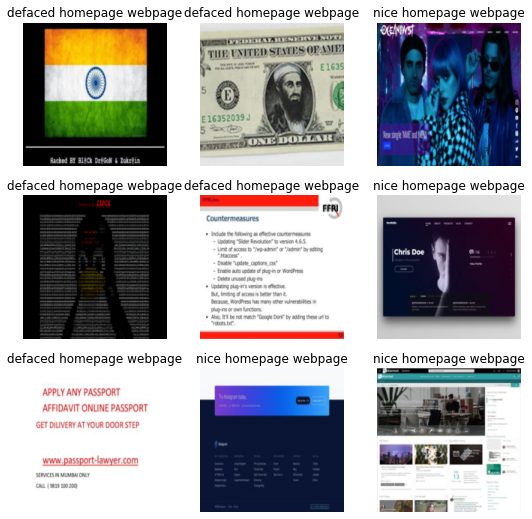

In [43]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=9)

Here what each of the `DataBlock` parameters means:

    blocks=(ImageBlock, CategoryBlock),

The inputs to our model are images, and the outputs are categories (in this case, "defaced" or "non-defaced").

    get_items=get_image_files, 

To find all the inputs to our model, run the `get_image_files` function (which returns a list of all image files in a path).

    splitter=RandomSplitter(valid_pct=0.2, seed=42),

Split the data into training and validation sets randomly, using 20% of the data for the validation set.

    get_y=parent_label,

The labels (`y` values) is the name of the `parent` of each file (i.e. the name of the folder they're in, which will be *defaced* or *non-defaced*).

    item_tfms=[Resize(192, method='squish')]

Before training, resize each image to 192x192 pixels by "squishing" it (as opposed to cropping it).

Now we're ready to train our model. The fastest widely used computer vision model is `resnet18`. You can train this in a few minutes, even on a CPU! (On a GPU, it generally takes under 10 seconds...)

`fastai` comes with a helpful `fine_tune()` method which automatically uses best practices for fine tuning a pre-trained model, so we'll use that.

Here is the trick: we use something called transfer learning. We borrow the knowledge from a very big pre-trained model like `resnet18` and customize that knowledge for our use case. It's like getting knowledge about mathematics in general and then getting specialized in derivatives 

"Fine-tuning" a model means that we're starting with a model someone else has trained using some other dataset (called the *pretrained model*), and adjusting the weights a little bit so that the model learns to recognise your particular dataset. In this case, the pretrained model was trained to recognise photos in *imagenet*, and widely-used computer vision dataset with images covering 1000 categories) For details on fine-tuning and why it's important, check out the [free fast.ai course](https://course.fast.ai/).

In [44]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(8)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,1.114468,1.405217,0.347826,00:09


epoch,train_loss,valid_loss,error_rate,time
0,0.681847,0.731658,0.243478,00:03
1,0.541233,0.698965,0.217391,00:02
2,0.445121,0.774025,0.191304,00:03
3,0.371710,0.854847,0.182609,00:02
4,0.318104,0.701445,0.191304,00:03
5,0.276824,0.682265,0.173913,00:02
6,0.242588,0.707648,0.173913,00:03
7,0.217840,0.689942,0.173913,00:03


We get 80% accuracy on the validation dataset which is great for a first try 🥳

## Step 3: Use the model

Let's see what our model thinks about that defaced.jpg we downloaded at the start:

In [46]:
is_defaced,_,probs = learn.predict(PILImage.create('defaced.jpg'))
print(f"This is a: {is_defaced}.")
print(f"Probability it's a defaced: {probs[0]:.4f}")

This is a: defaced homepage webpage.
Probability it's a defaced: 0.5223


## Conclusions
In this short blog post, we constructed a simple classifier to detect web defacement. Our classifier gets 80% accuracy on the validation dataset. I will continue to improve it as I follow the course, so stay tuned 😎

This post is based on the [first lab](https://www.kaggle.com/code/jhoward/is-it-a-bird-creating-a-model-from-your-own-data) of the [fast.ai](https://course.fast.ai) coure so thank you [Jeremy Howard](https://twitter.com/jeremyphoward) 😃
![](https://pbs.twimg.com/media/Ff_o_toXgAELiDm?format=jpg&name=medium)